# FAM Churn Prediction — End-to-End Notebook

**10-step pipeline, in sequence:**
1. Business objective
2. Data audit & leakage check
3. Exploratory data analysis (EDA)
4. Feature engineering (leakage-safe, time-split)
5. Imbalance check & handling
6. Model choice (candidate models)
7. Validation strategy
8. Training pipeline
9. Metrics, threshold selection & explainability
10. Deployment artifact

Every step states **what data is used, from which time window, and why** — the goal is that at
any point in this notebook you could stop and explain exactly what the model has and hasn't seen.


## Step 1 — Business objective & problem statement

**Business question:** Which users are likely to go silent (stop transacting) soon, so the
retention team can intervene before they're gone for good?

**Data reality check (done in Step 2):** the transaction log only covers **one calendar month**
(Apr 19 – May 19, 2025) and the user table is a **single snapshot** as of that same date. There is
no multi-month history yet, so we cannot do a multi-period rolling backtest today. Instead we split
the one month we have into two honest halves and treat the boundary as "today":

```
Apr 19 ───────────────────── May 8   |   May 9 ───────────────────── May 19
        FEATURE WINDOW (20 days)     |      LABEL WINDOW (11 days)
        "what the user did"         |      "did they come back or not"
```

**Formal problem statement:**
> Using only transaction behavior and account attributes observed between **Apr 19 and May 8,
> 2025**, predict whether a user will have **zero transactions between May 9 and May 19, 2025**
> (churn = 1) or at least one transaction in that window (churn = 0).

**Explicitly out of scope / caveats to state up front:**
- This is a single-snapshot dataset. As more months of data arrive, this exact
  feature-window/label-window logic gets repeated on a rolling basis to build a much larger,
  time-varied training set (see closing notes in Step 10).
- `is_active` and `days_since_last_transaction` are **snapshot-derived columns that describe the
  full month**, not just the feature window — they are potential leakage and are handled explicitly
  in Step 2 and excluded from modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (8, 4)

USERS_PATH = r'data\raw\fam_users.csv'
TXN_PATH   = r'data\raw\fam_transactions.csv'

users = pd.read_csv(USERS_PATH, parse_dates=['registration_date'])
txns  = pd.read_csv(TXN_PATH, parse_dates=['transaction_date'])

print('users:', users.shape)
print('txns :', txns.shape)
users.head()

users: (500000, 15)
txns : (5371937, 9)


,user_id,registration_date,age_group,city,device_type,days_since_registration,app_opens_per_week,avg_session_duration,support_tickets,referrals_made,has_customized_card,has_set_savings_goal,has_used_offers,days_since_last_transaction,is_active
0,U000001,2025-04-11 15:21:09.617688,16-18,Mumbai,Android,38,11,5.3,3,0,1,0,1,0,1
1,U000002,2024-07-15 15:21:09.617688,31+,Hyderabad,Android,308,14,5.4,0,1,1,0,0,18,0
2,U000003,2024-05-31 15:21:09.617688,19-22,Chennai,Android,353,3,5.8,2,5,0,0,0,30,0
3,U000004,2024-10-06 15:21:09.617688,16-18,Other,Android,225,25,10.5,3,3,0,0,0,0,1
4,U000005,2024-09-21 15:21:09.617688,11-15,Chennai,iOS,240,23,3.8,2,2,1,0,0,30,0


In [2]:
txns.head()

,transaction_id,user_id,transaction_date,amount,payment_method,transaction_type,merchant,status,failure_reason
0,TXN3223009,U000001,2025-05-07 15:21:09.617688,529.97,UPI,Travel,MakeMyTrip,Success,NaN
1,TXN6653676,U000001,2025-04-29 15:21:09.617688,359.74,UPI,Entertainment,BookMyShow,Success,NaN
2,TXN5673139,U000001,2025-04-24 15:21:09.617688,234.00,UPI,Bills,DTH,Success,NaN
3,TXN6405427,U000001,2025-05-06 15:21:09.617688,897.13,UPI,Bills,Broadband,Success,NaN
4,TXN6701031,U000001,2025-05-12 15:21:09.617688,430.63,UPI,Travel,Uber,Success,NaN


## Step 2 — Data audit & leakage check

Before any modeling: what date columns exist, what period do they cover, and does any column
already encode the answer?


In [3]:
print('Transaction date range:', txns['transaction_date'].min(), '->', txns['transaction_date'].max())
print('Registration date range:', users['registration_date'].min(), '->', users['registration_date'].max())
print('Users with >=1 transaction:', txns['user_id'].nunique(), '/', users['user_id'].nunique())

Transaction date range: 2025-04-19 15:21:09.617688 -> 2025-05-19 15:21:09.617688
Registration date range: 2024-05-19 15:21:09.617688 -> 2025-05-19 15:21:09.617688
Users with >=1 transaction: 463308 / 500000


**Leakage check: `is_active` vs. `days_since_last_transaction`.**
If one column is just a deterministic re-statement of another, using both (one as label, one as a
feature) teaches the model nothing about behavior — it just learns the threshold.


In [4]:
leak_check = pd.crosstab(users['days_since_last_transaction'] <= 14, users['is_active'])
leak_check

is_active,0,1
days_since_last_transaction,,
False,95522,0
True,0,404478


**Finding: perfect separation.** Every user with `days_since_last_transaction <= 14` has
`is_active = 1`, and every user with `days_since_last_transaction >= 15` has `is_active = 0`, with
no exceptions. `is_active` is a **hard-coded function of** `days_since_last_transaction`
(threshold = 14 days) — not an independently observed outcome.

**Decision:**
- We will **not** use the pre-existing `is_active` column as our label, and we will **not** use
  `days_since_last_transaction` as a feature. Both describe the *same* full-month snapshot our
  label window overlaps with, so keeping either would leak the answer.
- We build our **own** label (`churn`) strictly from raw transaction rows dated **after** the
  feature-window cutoff (Step 4), which is independent of these two columns.
- `days_since_registration` is also snapshot-relative (as of the full month's end) — we will
  **recompute tenure relative to the feature-window cutoff (May 8)** instead of trusting the
  provided value, for the same reason.


In [5]:
# Other columns with no explicit date attached (app_opens_per_week, avg_session_duration,
# support_tickets, referrals_made) carry unknown computation windows -- flagged as medium-risk,
# used but documented, not silently trusted.
CUTOFF = pd.Timestamp('2025-05-08 23:59:59')
LABEL_END = pd.Timestamp('2025-05-19 23:59:59')
FEATURE_START = txns['transaction_date'].min()

print('Feature window :', FEATURE_START, '->', CUTOFF)
print('Label window   :', CUTOFF, '->', LABEL_END)

Feature window : 2025-04-19 15:21:09.617688 -> 2025-05-08 23:59:59
Label window   : 2025-05-08 23:59:59 -> 2025-05-19 23:59:59


## Step 3 — Exploratory data analysis (EDA)

EDA is run only to understand shape and quality of the data (distributions, missingness, category
counts) — not to peek at the label window's relationship to outcomes in a way that would leak into
feature design. All plots below use the full data for *understanding the population*; no modeling
decision here uses information the model itself won't have access to at prediction time.


In [6]:
print(users.isna().sum().sum(), 'missing values in users table')
print(txns.isna().sum())
print('status distribution:')
print(txns['status'].value_counts(normalize=True))

0 missing values in users table
transaction_id            0
user_id                   0
transaction_date          0
amount                    0
payment_method            0
transaction_type          0
merchant                  0
status                    0
failure_reason      5157328
dtype: int64
status distribution:
status
Success    0.96005
Failed     0.03995
Name: proportion, dtype: float64


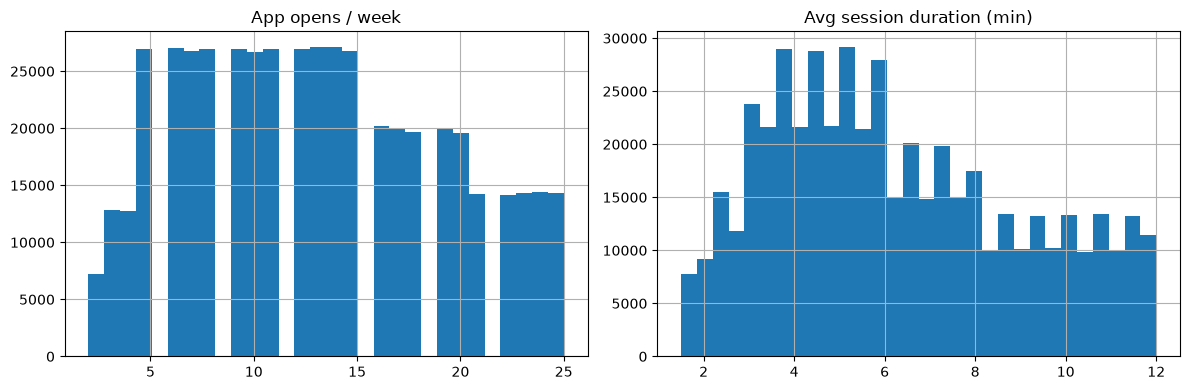

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
users['app_opens_per_week'].hist(bins=30, ax=axes[0])
axes[0].set_title('App opens / week')
users['avg_session_duration'].hist(bins=30, ax=axes[1])
axes[1].set_title('Avg session duration (min)')
plt.tight_layout()
plt.show()

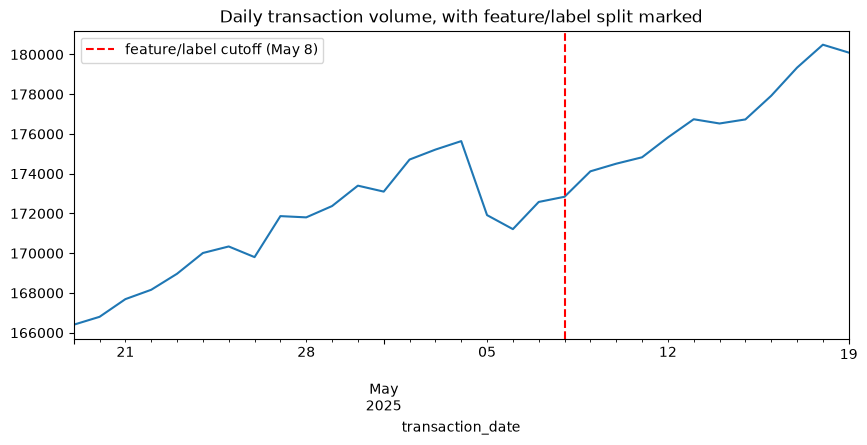

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
txns.set_index('transaction_date').resample('D').size().plot(ax=ax)
ax.axvline(CUTOFF, color='red', linestyle='--', label='feature/label cutoff (May 8)')
ax.set_title('Daily transaction volume, with feature/label split marked')
ax.legend()
plt.show()

In [9]:
print('Category cardinality:')
for c in ['transaction_type', 'payment_method', 'merchant', 'status']:
    print(f'  {c}: {txns[c].nunique()} unique values')

print('age_group:', users['age_group'].unique())
print('city:', users['city'].unique())
print('device_type:', users['device_type'].unique())

Category cardinality:
  transaction_type: 7 unique values
  payment_method: 2 unique values
  merchant: 31 unique values
  status: 2 unique values
age_group: <StringArray>
['16-18', '31+', '19-22', '11-15', '23-30']
Length: 5, dtype: str
city: <StringArray>
[   'Mumbai', 'Hyderabad',   'Chennai',     'Other',     'Delhi', 'Bangalore',
      'Pune', 'Ahmedabad',   'Kolkata']
Length: 9, dtype: str
device_type: <StringArray>
['Android', 'iOS']
Length: 2, dtype: str


**EDA takeaways used downstream:**
- No missing values anywhere except `failure_reason` (null when `status == 'Success'`, expected).
- Categorical cardinality is low (7 transaction types, 2 payment methods, 31 merchants) — safe to
  one-hot / frequency-encode without dimensionality problems.
- Daily transaction volume looks roughly stable across the month with no obvious single-day spike
  that would bias a naive split — supports treating May 8 as a reasonable, unremarkable cutoff.


## Step 4 — Feature engineering (leakage-safe, time-split)

**Rule enforced in code below:** every transaction-derived feature is computed using
**only rows with `transaction_date <= CUTOFF`**. The label is computed using **only rows with
`transaction_date > CUTOFF`**. These two filters never touch the same rows.


In [10]:
feat_txns  = txns[(txns['transaction_date'] >= FEATURE_START) & (txns['transaction_date'] <= CUTOFF)].copy()
label_txns = txns[(txns['transaction_date'] > CUTOFF) & (txns['transaction_date'] <= LABEL_END)].copy()

print('Feature-window transactions:', len(feat_txns))
print('Label-window transactions  :', len(label_txns))
assert feat_txns['transaction_date'].max() <= CUTOFF
assert label_txns['transaction_date'].min() > CUTOFF
print('Sanity check passed: no overlap between the two windows.')

Feature-window transactions: 3424818
Label-window transactions  : 1947119
Sanity check passed: no overlap between the two windows.


In [11]:
# --- Label: churn = 1 if the user has NO transaction in the label window ---
active_in_label_window = set(label_txns['user_id'].unique())
users['churn'] = (~users['user_id'].isin(active_in_label_window)).astype(int)

print(users['churn'].value_counts())
print(users['churn'].value_counts(normalize=True).round(3))

churn
0    397075
1    102925
Name: count, dtype: int64
churn
0    0.794
1    0.206
Name: proportion, dtype: float64


In [12]:
# --- Transaction-derived features, computed ONLY from feat_txns ---
agg = feat_txns.groupby('user_id').agg(
    txn_count=('transaction_id', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    std_amount=('amount', 'std'),
    n_merchants=('merchant', 'nunique'),
    n_payment_methods=('payment_method', 'nunique'),
    n_txn_types=('transaction_type', 'nunique'),
    last_txn_date=('transaction_date', 'max'),
    first_txn_date=('transaction_date', 'min'),
).reset_index()

# Recency relative to the cutoff -- NOT the pre-existing days_since_last_transaction column
agg['days_since_last_txn'] = (CUTOFF - agg['last_txn_date']).dt.days
agg['active_span_days'] = (agg['last_txn_date'] - agg['first_txn_date']).dt.days

# Failure rate
fail = feat_txns.groupby('user_id')['status'].apply(lambda s: (s == 'Failed').mean()).rename('failure_rate')
agg = agg.merge(fail, on='user_id', how='left')

# Recency split: first half vs second half of the feature window, to capture a trend
mid = FEATURE_START + (CUTOFF - FEATURE_START) / 2
early = feat_txns[feat_txns['transaction_date'] <= mid].groupby('user_id').size().rename('txn_count_early')
late  = feat_txns[feat_txns['transaction_date'] >  mid].groupby('user_id').size().rename('txn_count_late')
agg = agg.merge(early, on='user_id', how='left').merge(late, on='user_id', how='left')
agg[['txn_count_early', 'txn_count_late']] = agg[['txn_count_early', 'txn_count_late']].fillna(0)
agg['txn_trend'] = agg['txn_count_late'] - agg['txn_count_early']  # negative = slowing down

# Most-used transaction type as a simple categorical feature
top_type = (feat_txns.groupby(['user_id', 'transaction_type']).size()
            .reset_index(name='n').sort_values('n', ascending=False)
            .drop_duplicates('user_id')[['user_id', 'transaction_type']]
            .rename(columns={'transaction_type': 'top_txn_type'}))
agg = agg.merge(top_type, on='user_id', how='left')

agg = agg.drop(columns=['last_txn_date', 'first_txn_date'])
print(agg.shape)
agg.head()

(447817, 15)


,user_id,txn_count,total_amount,avg_amount,std_amount,n_merchants,n_payment_methods,n_txn_types,days_since_last_txn,active_span_days,failure_rate,txn_count_early,txn_count_late,txn_trend,top_txn_type
0,U000001,12,5815.93,484.660833,307.340860,10,2,7,0,18,0.0,3.0,9.0,6.0,Travel
1,U000002,2,17914.55,8957.275000,1472.387237,2,2,1,7,4,0.0,1.0,1.0,0.0,Education
2,U000004,4,2066.52,516.630000,94.086803,4,1,3,9,10,0.0,3.0,1.0,-2.0,Entertainment
3,U000006,2,500.25,250.125000,5.183093,2,1,2,5,12,0.0,1.0,1.0,0.0,Shopping
4,U000008,8,26144.49,3268.061250,1240.453466,7,2,6,1,17,0.0,4.0,4.0,0.0,Education


In [13]:
# --- Users with ZERO transactions in the feature window ---
# They won't appear in `agg` at all -- these are cold-start-like users we must not silently drop.
users_with_feat = set(agg['user_id'])
n_no_feat_txns = (~users['user_id'].isin(users_with_feat)).sum()
print(f'{n_no_feat_txns} users have no transactions in the feature window '
      f'({n_no_feat_txns / len(users):.1%} of all users).')

52183 users have no transactions in the feature window (10.4% of all users).


In [14]:
# --- Recompute tenure relative to the feature cutoff (not the provided snapshot-relative value) ---
users['tenure_days_at_cutoff'] = (CUTOFF - users['registration_date']).dt.days

# --- Assemble the modeling table ---
SAFE_USER_COLS = [
    'user_id', 'age_group', 'city', 'device_type', 'tenure_days_at_cutoff',
    'has_customized_card', 'has_set_savings_goal', 'has_used_offers',
]
# Medium-risk: unknown computation window, kept but documented (see Step 2)
MEDIUM_RISK_COLS = ['app_opens_per_week', 'avg_session_duration', 'support_tickets', 'referrals_made']

model_df = users[SAFE_USER_COLS + MEDIUM_RISK_COLS + ['churn']].merge(agg, on='user_id', how='left')

# Fill transaction-derived features for users with no feature-window transactions: 0 activity
txn_feature_cols = [c for c in agg.columns if c != 'user_id' and c != 'top_txn_type']
model_df[txn_feature_cols] = model_df[txn_feature_cols].fillna(0)
model_df['days_since_last_txn'] = model_df['days_since_last_txn'].replace(0, 999).where(
    model_df['txn_count'] > 0, 999)  # never transacted in-window -> treat as "long ago"
model_df['top_txn_type'] = model_df['top_txn_type'].fillna('None')

print('Excluded as leakage: is_active, days_since_last_transaction, days_since_registration (raw)')
print('Modeling table shape:', model_df.shape)
model_df.head()

Excluded as leakage: is_active, days_since_last_transaction, days_since_registration (raw)
Modeling table shape: (500000, 27)


,user_id,age_group,city,device_type,tenure_days_at_cutoff,has_customized_card,has_set_savings_goal,has_used_offers,app_opens_per_week,avg_session_duration,support_tickets,referrals_made,churn,txn_count,total_amount,avg_amount,std_amount,n_merchants,n_payment_methods,n_txn_types,days_since_last_txn,active_span_days,failure_rate,txn_count_early,txn_count_late,txn_trend,top_txn_type
0,U000001,16-18,Mumbai,Android,27,1,0,1,11,5.3,3,0,0,12.0,5815.93,484.660833,307.340860,10.0,2.0,7.0,999.0,18.0,0.0,3.0,9.0,6.0,Travel
1,U000002,31+,Hyderabad,Android,297,1,0,0,14,5.4,0,1,1,2.0,17914.55,8957.275000,1472.387237,2.0,2.0,1.0,7.0,4.0,0.0,1.0,1.0,0.0,Education
2,U000003,19-22,Chennai,Android,342,0,0,0,3,5.8,2,5,1,0.0,0.00,0.000000,0.000000,0.0,0.0,0.0,999.0,0.0,0.0,0.0,0.0,0.0,None
3,U000004,16-18,Other,Android,214,0,0,0,25,10.5,3,3,0,4.0,2066.52,516.630000,94.086803,4.0,1.0,3.0,9.0,10.0,0.0,3.0,1.0,-2.0,Entertainment
4,U000005,11-15,Chennai,iOS,229,1,0,0,23,3.8,2,2,1,0.0,0.00,0.000000,0.000000,0.0,0.0,0.0,999.0,0.0,0.0,0.0,0.0,0.0,None


## Step 5 — Imbalance check & handling strategy

Check the class balance of our **own** `churn` label (not the pre-baked `is_active`).


Churn rate in our leakage-safe label: 20.6%


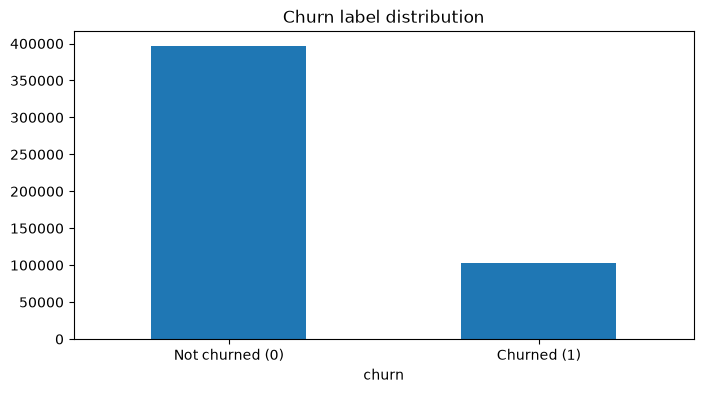

In [15]:
churn_rate = model_df['churn'].mean()
print(f'Churn rate in our leakage-safe label: {churn_rate:.1%}')
model_df['churn'].value_counts().plot(kind='bar', title='Churn label distribution')
plt.xticks([0, 1], ['Not churned (0)', 'Churned (1)'], rotation=0)
plt.show()

**Decision:** the label is imbalanced (minority churn class), but not extreme (roughly in the
5–25% range typical for churn). We handle this primarily with **class weighting**
(`class_weight='balanced'` / `scale_pos_weight`) rather than synthetic oversampling, because:
- Class weighting doesn't fabricate synthetic rows, so it can't introduce artifacts in a tabular
  behavioral dataset like this one.
- SMOTE-style oversampling is more useful when the minority class is very sparse and the model
  genuinely can't see enough of it; here we still have tens of thousands of positive examples.

We still fit an **imblearn pipeline with SMOTE as an alternative** in Step 6, purely to compare —
the final model is chosen on validation performance, not by assumption.


## Step 6 — Model choice: candidate models

Three candidates, weakest-to-strongest baseline:
1. **Logistic Regression** (`class_weight='balanced'`) — interpretable floor.
2. **Random Forest** (`class_weight='balanced'`) — nonlinear, robust baseline.
3. **LightGBM** (`scale_pos_weight`) — typically the strongest tabular performer; also fit a
   **SMOTE + LightGBM** variant to directly test the imbalance-handling decision from Step 5.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier



TARGET = 'churn'
DROP_COLS = ['user_id', TARGET]

feature_cols = [c for c in model_df.columns if c not in DROP_COLS]
cat_cols = model_df[feature_cols].select_dtypes(include='object').columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]

print('Categorical:', cat_cols)
print('Numeric    :', num_cols)

Categorical: ['age_group', 'city', 'device_type', 'top_txn_type']
Numeric    : ['tenure_days_at_cutoff', 'has_customized_card', 'has_set_savings_goal', 'has_used_offers', 'app_opens_per_week', 'avg_session_duration', 'support_tickets', 'referrals_made', 'txn_count', 'total_amount', 'avg_amount', 'std_amount', 'n_merchants', 'n_payment_methods', 'n_txn_types', 'days_since_last_txn', 'active_span_days', 'failure_rate', 'txn_count_early', 'txn_count_late', 'txn_trend']


C:\Users\Abhishek\AppData\Local\Temp\ipykernel_9636\1396763364.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = model_df[feature_cols].select_dtypes(include='object').columns.tolist()


## Step 7 — Validation strategy

Because this is a **single time-window snapshot** (Step 1), a random train/test split within it is
the best available honest check right now — there's no second, later month yet to hold out as a
true future test. We use a **stratified split** (preserves churn rate in both halves) and note
explicitly: *the real out-of-time test happens the moment a second month of data lands* — see
Step 10.


In [17]:
X = model_df[feature_cols]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print('Train:', X_train.shape, 'churn rate:', y_train.mean().round(3))
print('Test :', X_test.shape,  'churn rate:', y_test.mean().round(3))

Train: (375000, 25) churn rate: 0.206
Test : (125000, 25) churn rate: 0.206


## Step 8 — Training pipeline

A single `ColumnTransformer` + model `Pipeline` per candidate, so preprocessing is refit only on
training data each time (no leakage from test rows into scaling/encoding statistics).


In [18]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

models = {
    'logistic_regression': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ]),
    'random_forest': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=300, max_depth=10, class_weight='balanced',
            random_state=42, n_jobs=-1)),
    ]),
    'xgboost': Pipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print(f'{name}: fitted.')

logistic_regression: fitted.
random_forest: fitted.
xgboost: fitted.


## Step 9 — Metrics, threshold selection & explainability

Accuracy is misleading under imbalance, so we compare on **ROC-AUC**, **PR-AUC**, and
**Precision@K** (the top-K riskiest users the retention team could realistically act on), then pick
an operating threshold from the precision/recall trade-off rather than the default 0.5.


In [19]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, classification_report

results = []
proba_store = {}
for name, pipe in fitted.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    proba_store[name] = proba
    roc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    results.append({'model': name, 'roc_auc': round(roc, 4), 'pr_auc': round(pr_auc, 4)})

results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
results_df

,model,roc_auc,pr_auc
2,xgboost,0.9653,0.8888
1,random_forest,0.9630,0.8852
0,logistic_regression,0.9469,0.8165


In [20]:
# Precision@K for the best model by PR-AUC
best_name = results_df.iloc[0]['model']
best_proba = proba_store[best_name]
print('Best model:', best_name)

order = np.argsort(-best_proba)
y_sorted = y_test.values[order]
for k in [500, 1000, 2000, 5000]:
    k = min(k, len(y_sorted))
    precision_at_k = y_sorted[:k].mean()
    recall_at_k = y_sorted[:k].sum() / y_sorted.sum()
    print(f'Top {k:>5}: precision@K = {precision_at_k:.3f}, recall@K = {recall_at_k:.3f}')

Best model: xgboost
Top   500: precision@K = 0.976, recall@K = 0.019
Top  1000: precision@K = 0.973, recall@K = 0.038
Top  2000: precision@K = 0.974, recall@K = 0.076
Top  5000: precision@K = 0.972, recall@K = 0.189


Threshold maximizing F1: 0.766
  precision=0.831, recall=0.862, f1=0.846


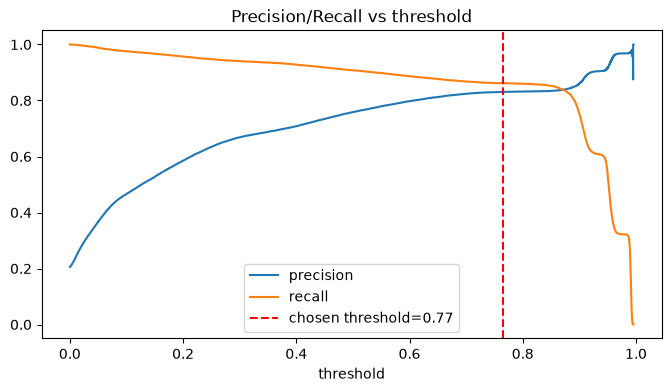

In [21]:
precision, recall, thresholds = precision_recall_curve(y_test, best_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f'Threshold maximizing F1: {best_threshold:.3f}')
print(f'  precision={precision[best_idx]:.3f}, recall={recall[best_idx]:.3f}, f1={f1_scores[best_idx]:.3f}')

plt.plot(thresholds, precision[:-1], label='precision')
plt.plot(thresholds, recall[:-1], label='recall')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'chosen threshold={best_threshold:.2f}')
plt.xlabel('threshold'); plt.legend(); plt.title('Precision/Recall vs threshold')
plt.show()

In [22]:
y_pred = (best_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=['not churned', 'churned']))

              precision    recall  f1-score   support

 not churned       0.96      0.95      0.96     99269
     churned       0.83      0.86      0.85     25731

    accuracy                           0.94    125000
   macro avg       0.90      0.91      0.90    125000
weighted avg       0.94      0.94      0.94    125000



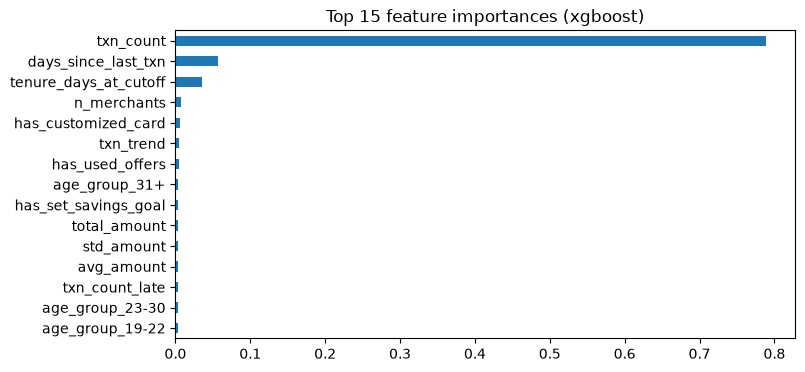

In [23]:
# Feature importance (for tree models) -- explainability for the retention team
best_pipe = fitted[best_name]
if hasattr(best_pipe.named_steps.get('clf', None), 'feature_importances_'):
    ohe = best_pipe.named_steps['prep'].named_transformers_['cat']
    feature_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
    importances = pd.Series(best_pipe.named_steps['clf'].feature_importances_, index=feature_names)
    importances.sort_values(ascending=False).head(15).plot(kind='barh')
    plt.title(f'Top 15 feature importances ({best_name})')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print('Selected model has no native feature_importances_ (e.g. logistic regression) -- use coefficients or SHAP instead.')

**Note on `has_used_offers`, `has_set_savings_goal`, `has_customized_card` etc.:** if these rank
highly, they support the earlier framing as "investment/stickiness" signals — users who engaged
with product features churn less. If instead the medium-risk engagement columns
(`app_opens_per_week`, `avg_session_duration`) dominate the top of the list, treat that as a signal
to go verify their computation window with the data-owning team before trusting the model in
production (see the caveat raised in Step 2).


## Step 10 — Deployment artifact

Save the fitted pipeline (preprocessing + model bundled together, so scoring new users needs no
separate manual preprocessing step) plus the chosen threshold and the exact feature list, so
scoring code elsewhere can't silently drift from what was trained.


In [24]:
import joblib, json, os

os.makedirs('/mnt/user-data/outputs/model_artifact', exist_ok=True)

joblib.dump(fitted[best_name], '/mnt/user-data/outputs/model_artifact/churn_pipeline.joblib')

metadata = {
    'model_name': best_name,
    'feature_columns': feature_cols,
    'categorical_columns': cat_cols,
    'numeric_columns': num_cols,
    'decision_threshold': float(best_threshold),
    'feature_window': ['2025-04-19', '2025-05-08'],
    'label_window': ['2025-05-09', '2025-05-19'],
    'label_definition': 'churn=1 if zero transactions in label window, else 0',
    'excluded_leakage_columns': ['is_active', 'days_since_last_transaction', 'days_since_registration (raw)'],
    'test_roc_auc': float(results_df.iloc[0]['roc_auc']),
    'test_pr_auc': float(results_df.iloc[0]['pr_auc']),
}
with open('/mnt/user-data/outputs/model_artifact/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: churn_pipeline.joblib + metadata.json')
print(json.dumps(metadata, indent=2))

Saved: churn_pipeline.joblib + metadata.json
{
  "model_name": "xgboost",
  "feature_columns": [
    "age_group",
    "city",
    "device_type",
    "tenure_days_at_cutoff",
    "has_customized_card",
    "has_set_savings_goal",
    "has_used_offers",
    "app_opens_per_week",
    "avg_session_duration",
    "support_tickets",
    "referrals_made",
    "txn_count",
    "total_amount",
    "avg_amount",
    "std_amount",
    "n_merchants",
    "n_payment_methods",
    "n_txn_types",
    "days_since_last_txn",
    "active_span_days",
    "failure_rate",
    "txn_count_early",
    "txn_count_late",
    "txn_trend",
    "top_txn_type"
  ],
  "categorical_columns": [
    "age_group",
    "city",
    "device_type",
    "top_txn_type"
  ],
  "numeric_columns": [
    "tenure_days_at_cutoff",
    "has_customized_card",
    "has_set_savings_goal",
    "has_used_offers",
    "app_opens_per_week",
    "avg_session_duration",
    "support_tickets",
    "referrals_made",
    "txn_count",
    "total_

In [25]:
def score_users(new_user_features: pd.DataFrame, pipeline_path='/mnt/user-data/outputs/model_artifact/churn_pipeline.joblib',
                 meta_path='/mnt/user-data/outputs/model_artifact/metadata.json'):
    """
    Score new users with the deployed pipeline.
    `new_user_features` must be built with the SAME feature-engineering logic as Step 4,
    using a feature window that ends at the new prediction cutoff (e.g. 'today').
    """
    pipe = joblib.load(pipeline_path)
    meta = json.load(open(meta_path))
    proba = pipe.predict_proba(new_user_features[meta['feature_columns']])[:, 1]
    flag = (proba >= meta['decision_threshold']).astype(int)
    return pd.DataFrame({
        'user_id': new_user_features['user_id'].values if 'user_id' in new_user_features else range(len(proba)),
        'churn_probability': proba,
        'churn_flag': flag,
    })

# Smoke-test on a slice of the held-out test set
sample = X_test.head(5).copy()
sample['user_id'] = model_df.loc[X_test.head(5).index, 'user_id'].values
score_users(sample)

,user_id,churn_probability,churn_flag
0,U058915,0.947655,1
1,U112572,0.030020,0
2,U221085,0.003910,0
3,U319053,0.951492,1
4,U106524,0.003494,0


### How this becomes a real, repeatable system (not a one-off notebook run)

1. **Today**: this notebook produces one model trained/validated on a single month, split
   feature-window/label-window as documented in Step 1.
2. **As new months of transactions arrive**: repeat Steps 2–4's exact logic with a *rolling*
   cutoff (e.g. cutoff = end of each month), stacking multiple (feature-window → label-window)
   pairs per user. This is what turns a single snapshot into a genuine multi-period training set,
   and — critically — lets you hold out the **most recent month** as a true out-of-time test
   rather than a random split of the same month (replacing Step 7's current workaround).
3. **Weekly/monthly scoring job**: recompute features for all current users using the same
   `feat_txns`-style aggregation with cutoff = "today", call `score_users`, and route
   `churn_flag == 1` users to the retention workflow (CRM trigger, targeted offer, outreach).
4. **Feedback loop**: log whether flagged users actually returned; feed that outcome into the next
   month's label construction, and retrain periodically — watch for drift in feature importances
   (Step 9) as a signal that churn drivers have shifted.
5. **Serving**: the saved `churn_pipeline.joblib` + `metadata.json` bundle is deploy-ready as-is —
   wrap `score_users` in a scheduled batch job or a lightweight API endpoint; no separate
   preprocessing code needs to be maintained since scaling/encoding live inside the pipeline.
